# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

## Предсказание цен Airbnb в Нью-Йорке

Цель работы - построить модель для предсказания стоимости жилья на основе характеристик объекта и его расположения.

В работе были применены следующие этапы анализа и обработки данных.


### 1. Exploratory Data Analysis (EDA)

На этапе разведочного анализа данных были выполнены:

- анализ структуры данных (`df.info`, `df.describe`)
- анализ распределения целевой переменной price
- визуализация распределений признаков
- построение матрицы корреляций
- построение pairplot для анализа взаимосвязей между признаками

В результате анализа было выявлено:

- сильная асимметрия распределения цены
- наличие значительного количества выбросов
- слабая линейная корреляция между большинством признаков


### 2. Предобработка данных

Были применены следующие техники:

Удаление нерелевантных признаков  
Удалены признаки:

- id
- name
- host_id
- host_name
- last_review

Обработка пропусков  
Пропуски в признаке reviews_per_month были заполнены нулем.

Обработка выбросов  
Значения цены были ограничены:

price < 500

Это позволило уменьшить влияние экстремальных значений.

### 3. Feature Engineering

Были применены следующие методы улучшения признаков:

Логарифмирование целевой переменной  
Распределение цены было сильно асимметричным, поэтому была применена трансформация:

log_price = log(1 + price)

Создание нового признака  
Был создан признак:

distance_to_manhattan

Он отражает расстояние объекта до центра Манхэттена, это один из самых дорогих районов города.

Этот признак позволил учесть географическое влияние на цену.

Кодирование категориальных признаков  
Для признаков:

- neighbourhood_group
- room_type

было применено one-hot кодирование (dummy variables).

Масштабирование признаков  
Числовые признаки были масштабированы с использованием StandardScaler.

### 4. Использованные модели

Были построены следующие модели регрессии:

- Linear Regression
- RidgeCV
- LassoCV
- ElasticNetCV

Качество моделей оценивалось с помощью метрик:

- R²
- MAE
- RMSE

### 5. Результаты

Лучшие модели показали:

R² ≈ 0.54

Это означает, что модели объясняют примерно 54% вариации цены жилья.

## Часть 1. EDA

### Импорт библиотек 

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, RobustScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Загрузка данных

In [3]:
df = pd.read_csv("AB_NYC_2019.csv")

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Cтруктура данных

In [4]:
df.shape

(48895, 16)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

## Базовые статистики 

In [7]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


## Удаляем ненужные признаки

In [8]:
df = df.drop(columns=[
    "id",
    "name",
    "host_id",
    "host_name",
    "last_review"
])

## Проверяем пропуски 

In [9]:
df.isnull().sum()

neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

## Заполняем пропуски

In [10]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

## Распределение цены

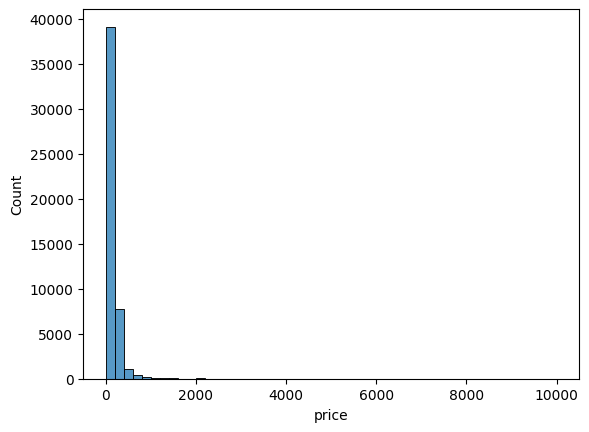

In [11]:
sns.histplot(df["price"], bins=50)
plt.show()

## Boxplot цены

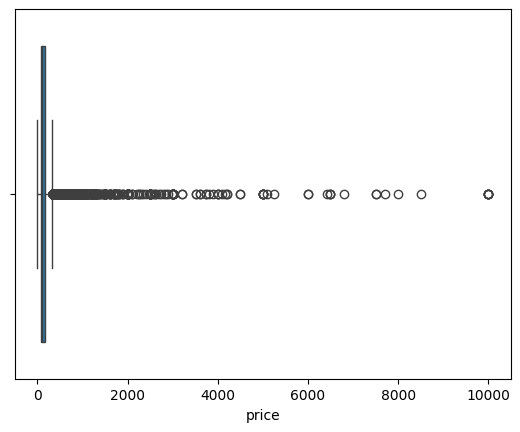

In [12]:
sns.boxplot(x=df["price"])
plt.show()

## Ограничим выбросы 

In [13]:
df = df[df["price"] < 500]

## Матрица корреляций 

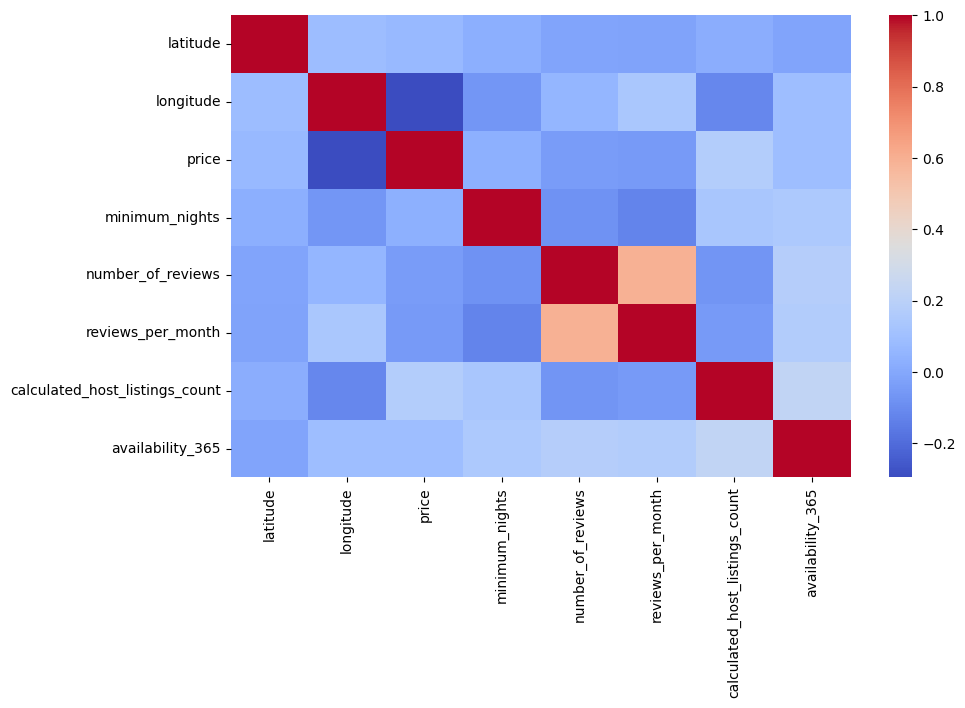

In [14]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")

plt.show()

## Pairplot

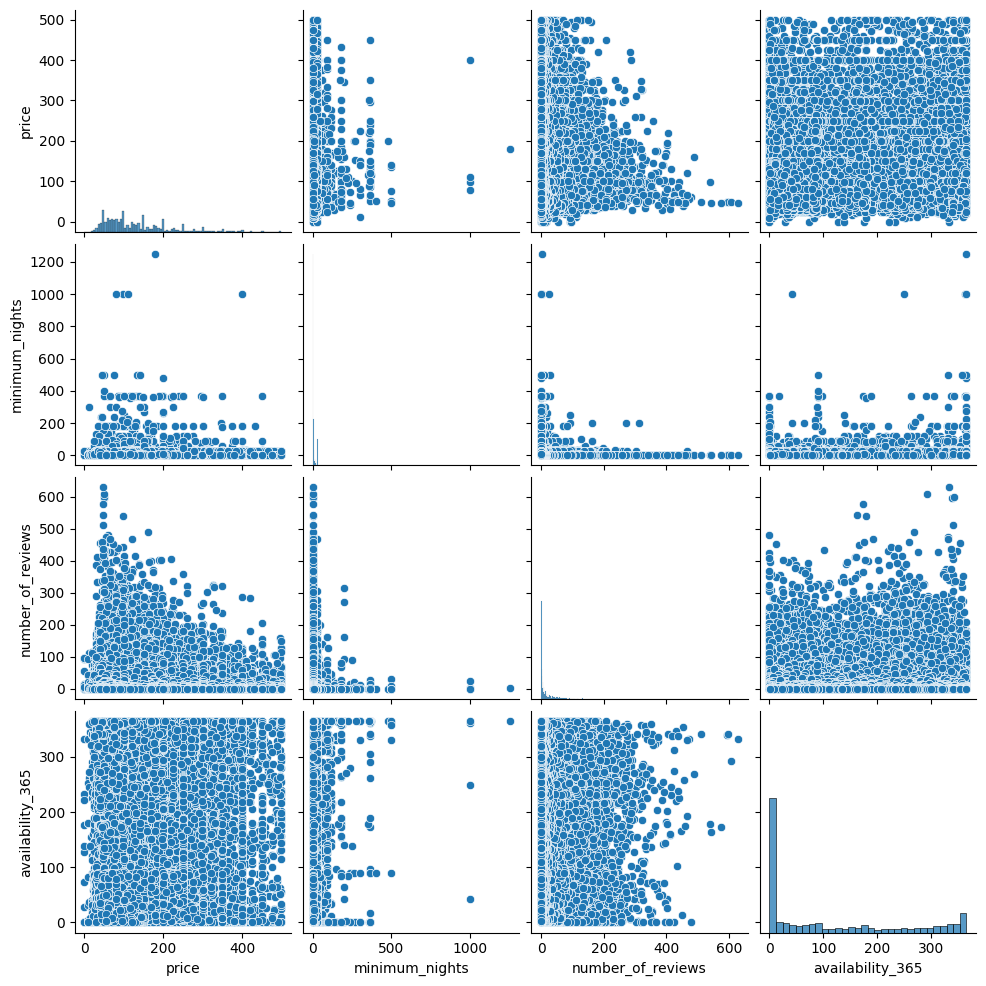

In [15]:
sns.pairplot(df[[
    "price",
    "minimum_nights",
    "number_of_reviews",
    "availability_365"
]])

plt.show()

### Предобработка данных

По результатам первичного анализа данных была выполнена предобработка признаков.

1. Пропущенные значения в признаке reviews_per_month были заполнены нулем, так как отсутствие отзывов может означать отсутствие активности.

2. Было обнаружено большое количество выбросов в переменной price. Для повышения устойчивости модели экстремальные значения были ограничены (price < 500).

# Часть 2. Preprocessing & Feature Engineering

## Кодирование категориальных переменных
Для категориальных признаков neighbourhood_group и room_type было применено one-hot кодирование (dummy encoding). Это позволяет преобразовать категориальные переменные в числовой формат, который может использоваться моделями машинного обучения.

In [16]:
df = pd.get_dummies(df, columns=[
    "neighbourhood_group",
    "room_type"
], drop_first=True)

## Преобразование целевой переменной

Распределение цены оказалось сильно асимметричным.  
Для уменьшения влияния выбросов было применено логарифмическое преобразование:

log_price = log(1 + price)

Это помогает улучшить стабильность и точность моделей.

In [17]:
df["log_price"] = np.log1p(df["price"])

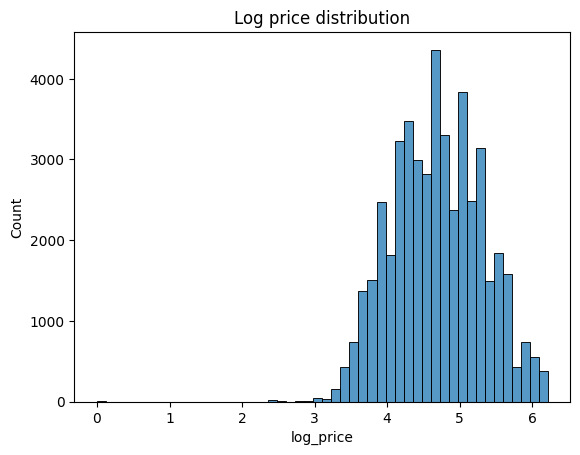

In [18]:
sns.histplot(df["log_price"], bins=50)
plt.title("Log price distribution")
plt.show()

## Создание нового признака

Был создан новый признак - расстояние до центра Манхэттена.

Манхэттен является одним из самых дорогих районов Нью-Йорка, поэтому расстояние до него может быть важным фактором, влияющим на цену жилья.

Расстояние было рассчитано на основе координат широты и долготы.

In [20]:
manhattan_lat = 40.7831
manhattan_lon = -73.9712

df["distance_to_manhattan"] = np.sqrt(
    (df["latitude"] - manhattan_lat)**2 +
    (df["longitude"] - manhattan_lon)**2
)

## Подготовка данных

In [21]:
df = df.drop(columns=["price", "neighbourhood"])

## Масштабирование признаков 
Для числовых признаков было применено стандартное масштабирование (StandardScaler).  
Это позволяет привести признаки к единому масштабу, что важно для корректной работы моделей машинного обучения.

In [22]:
X = df.drop(columns=["log_price"])
y = df["log_price"]

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Часть 3. Моделирование

## Разделение данных 
Данные были разделены на обучающую и тестовую выборки, 30% данных были отложены для тестирования модели.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42
)

## Метрики качества 
R² - основная метрика регрессии, MAE - средняя абсолютная ошибка, RMSE - корень из MSE

In [26]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

## Простая линейная регрессия 

In [27]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("R2:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression
R2: 0.5435258575520127
MAE: 0.3187276237632459
RMSE: 0.41629180200118254


## RidgeCV

In [28]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=[0.1, 1.0, 10.0])

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge")
print("R2:", r2_score(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

Ridge
R2: 0.5435365226767274
MAE: 0.31872684387673866
RMSE: 0.41628693882328643


## LassoCV

In [29]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso")
print("R2:", r2_score(y_test, y_pred_lasso))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

Lasso
R2: 0.5436115742637131
MAE: 0.3187206241630531
RMSE: 0.41625271453010754


## ElasticNetCV

In [30]:
from sklearn.linear_model import ElasticNetCV

elastic = ElasticNetCV(cv=5)

elastic.fit(X_train, y_train)

y_pred_elastic = elastic.predict(X_test)

print("ElasticNet")
print("R2:", r2_score(y_test, y_pred_elastic))
print("MAE:", mean_absolute_error(y_test, y_pred_elastic))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_elastic)))

ElasticNet
R2: 0.5436185941231659
MAE: 0.31872101952836046
RMSE: 0.4162495132583132


## Визуализация важности признаков 

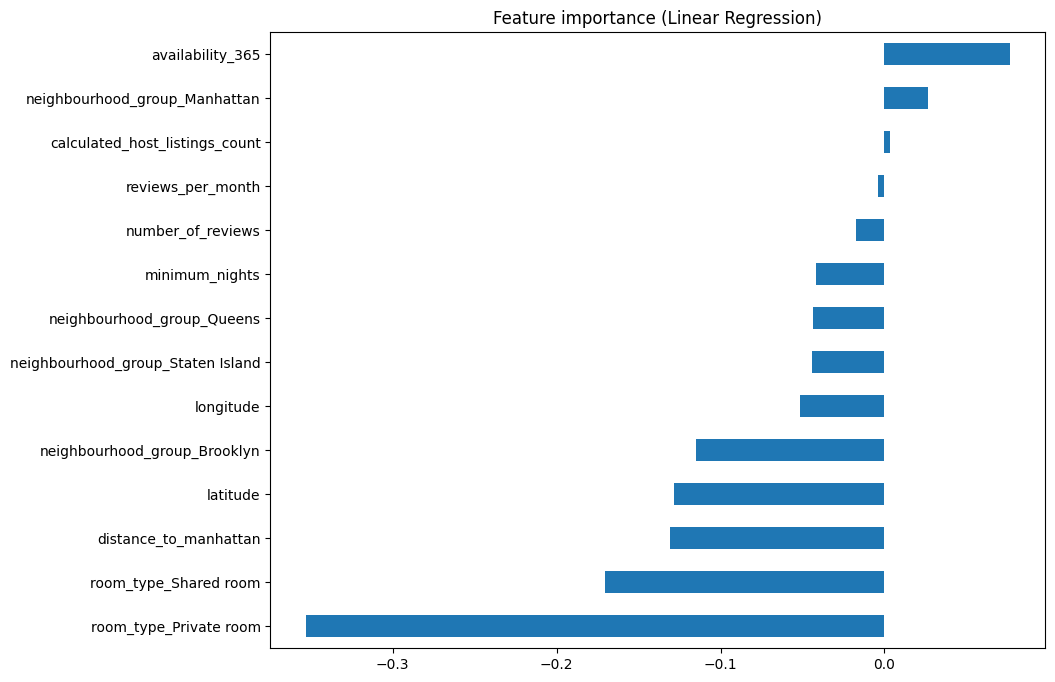

In [31]:
feature_names = X.columns

coefficients = pd.Series(lr.coef_, index=feature_names)

coefficients.sort_values().plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Feature importance (Linear Regression)")
plt.show()

## Выводы по моделированию

В рамках работы были построены четыре модели регрессии:

- Linear Regression
- RidgeCV
- LassoCV
- ElasticNetCV

Качество моделей оценивалось с помощью метрик R², MAE и RMSE.

Результаты моделей оказались практически одинаковыми:

Linear Regression:
R² ≈ 0.543  
MAE ≈ 0.319  
RMSE ≈ 0.416  

RidgeCV:
R² ≈ 0.544  
MAE ≈ 0.319  
RMSE ≈ 0.416  

LassoCV:
R² ≈ 0.544  
MAE ≈ 0.319  
RMSE ≈ 0.416  

ElasticNetCV:
R² ≈ 0.544  
MAE ≈ 0.319  
RMSE ≈ 0.416  

Регуляризованные модели (Ridge, Lasso, ElasticNet) показали результаты, практически совпадающие с простой линейной регрессией. Это говорит о том, что переобучение в данной задаче выражено слабо.

Коэффициент детерминации R² около 0.54 показывает, что модели объясняют примерно 54% вариации цен на жильё.